# AI Agent Debate — Results Analysis (Guidelines V3 §9)

This notebook is the **research & results-analysis** layer for the mediated debate engine. It is deliberately *thin*: all parsing and aggregation lives in the unit-tested `debate.analysis` module, so the notebook only **loads** saved artifacts and **visualizes** them.

**Research questions**

1. **Side bias** — across sessions, does the corner the Parent assigns at runtime (PRO vs CON) win equally often? A roughly even split is evidence the runtime side-assignment is unbiased and the verdict tracks persuasion.
2. **Margin** — how decisive are verdicts (`|pro_score - con_score|`)? Tight margins mean well-matched debaters.
3. **Evidence discipline** — how many citations does each role bring per turn?

**Data sources:** verdict JSONs and transcripts saved under `examples/` and `logs/` by real runs (`uv run python -m debate.main`). Add more runs to increase statistical power (see the sensitivity note at the end).

Run with the analysis extra installed: `uv sync --extra dev --extra analysis`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

# Resolve the repo root whether the notebook runs from notebooks/ or the
# root, and prefer the source tree over any installed copy of the package.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from debate.analysis import (
    dedupe_verdicts,
    load_verdicts,
    mean_citations_per_role,
    parse_transcript,
    summarize_verdicts,
)
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

verdicts = dedupe_verdicts(
    load_verdicts(ROOT / "examples") + load_verdicts(ROOT / "logs")
)
summary = summarize_verdicts(verdicts)
print(f"Loaded {summary.total} verdicts | PRO wins={summary.pro_wins} "
      f"CON wins={summary.con_wins} | mean margin={summary.mean_margin:.1f}")

Loaded 5 verdicts | PRO wins=1 CON wins=4 | mean margin=4.2


## 1. Side bias — wins by corner

If the runtime assignment were biased (or a side were hardcoded), one corner would win far more often. Across enough sessions we expect a roughly even split.

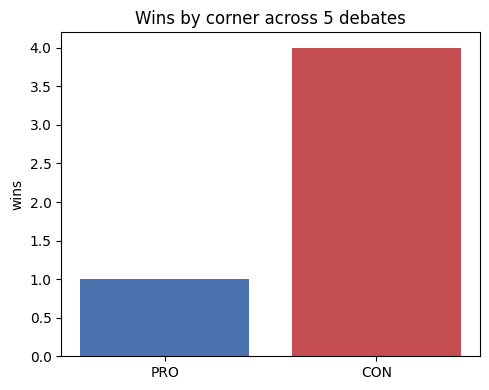

In [2]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["PRO", "CON"], [summary.pro_wins, summary.con_wins],
       color=["#4C72B0", "#C44E52"])
ax.set_title(f"Wins by corner across {summary.total} debates")
ax.set_ylabel("wins")
fig.tight_layout()
fig.savefig(RESULTS / "wins_by_corner.png", dpi=150)
plt.show()

## 2. Verdict margins and 3. evidence discipline

Left: how decisive verdicts are. Right: mean citations per turn for each role — a check that both debaters honour the one-source-per-turn rule.

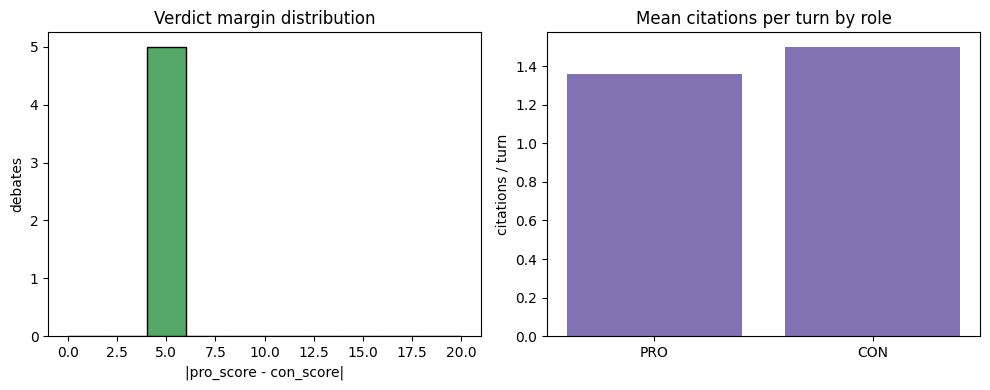

{'PRO': 1.36, 'CON': 1.5}

In [3]:
margins = [v.margin for v in verdicts]

turns = []
for tpath in sorted((ROOT / "examples").rglob("transcript*.md")):
    turns += parse_transcript(tpath.read_text(encoding="utf-8"))
for tpath in sorted((ROOT / "logs").rglob("transcript*.md")):
    turns += parse_transcript(tpath.read_text(encoding="utf-8"))
means = mean_citations_per_role(turns)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(margins or [0], bins=range(0, 22, 2),
             color="#55A868", edgecolor="black")
axes[0].set_title("Verdict margin distribution")
axes[0].set_xlabel("|pro_score - con_score|")
axes[0].set_ylabel("debates")
axes[1].bar(list(means) or ["PRO", "CON"], list(means.values()) or [0, 0],
            color="#8172B3")
axes[1].set_title("Mean citations per turn by role")
axes[1].set_ylabel("citations / turn")
fig.tight_layout()
fig.savefig(RESULTS / "margins_and_citations.png", dpi=150)
plt.show()
means

## Sensitivity analysis (how to extend)

The plots above summarise whatever runs are checked in. For a proper **sensitivity analysis** (Guidelines §9.1), generate more data by sweeping one parameter at a time (OAT) and re-running the engine, then re-run this notebook:

```powershell
# Vary pings-per-side (edit config/setup.json ‘pings_per_side’ or use the demo config)
uv run python -m debate.main --config config/demo_setup.json   # 5 pings
uv run python -m debate.main --config config/setup.json        # 10 pings

# Vary the topic to test side-bias on neutral ground
uv run python -m debate.main --topic "Tabs vs spaces" --pro "Tabs" --con "Spaces"
```

Each run appends a `verdict_<id>.json` and `transcript_<id>.md` to `logs/`, which this notebook picks up automatically. Suggested study: hold the topic fixed, vary `pings_per_side` ∈ {3, 5, 10}, run N sessions each, and plot mean verdict margin vs. pings to see whether longer debates produce more decisive outcomes.